In [213]:
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from typing import Dict, Any
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import lightgbm as lgb
from src.config import config

warnings.filterwarnings("ignore")

In [214]:

CSV_PATH = os.getenv("CSV_PATH")
DATE_COL = os.getenv("DATE_COL")
COMPANY_COL = os.getenv("COMPANY_COL")
FORECAST_DAYS = 30
SEASONAL_PERIOD = 7  # Sazonalidade diária -> 7 (semanal)
METRICS_CSV = os.getenv("METRICS_CSV")

In [215]:
def parse_and_prep(csv_path: str) -> pd.DataFrame:
    """Carrega, limpa e prepara os dados de reclamações."""
    print("Iniciando preparação de dados...")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Arquivo CSV não encontrado em: {csv_path}")

    df = pd.read_csv(csv_path, dtype=str)
    df.columns = [c.strip() for c in df.columns]
    if DATE_COL not in df.columns or COMPANY_COL not in df.columns:
        raise ValueError(f"CSV precisa conter colunas '{DATE_COL}' e '{COMPANY_COL}'")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", dayfirst=False)
    df = df.dropna(subset=[DATE_COL, COMPANY_COL])
    df[COMPANY_COL] = df[COMPANY_COL].str.strip()
    df = df[[DATE_COL, COMPANY_COL]]
    df[DATE_COL] = df[DATE_COL].dt.normalize()
    print(f"Dados preparados. Total de linhas: {len(df)}")
    return df

In [216]:
def make_daily_series(df: pd.DataFrame, company: str) -> pd.Series:
    """Cria uma série temporal diária de contagem de tickets para uma companhia."""
    sub = df[df[COMPANY_COL] == company].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    s = sub.groupby(DATE_COL).size().rename("count")
    idx = pd.date_range(start=s.index.min(), end=s.index.max(), freq="D")
    s = s.reindex(idx, fill_value=0)
    s.index.name = DATE_COL
    return s

In [217]:
def create_lgb_features(series: pd.Series, lags=[1,7,14,30], windows=[7,30]) -> pd.DataFrame:
    """Cria features para o LightGBM (lags, médias móveis, info de data)."""
    df = pd.DataFrame(series).rename(columns={series.name: "y"})
    if series.name is None:
        df = df.rename(columns={df.columns[0]: "y"})

    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    for w in windows:
        df[f"roll_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"] = df["y"].shift(1).rolling(w).std().fillna(0)
    df["dayofweek"] = df.index.dayofweek
    df["day"] = df.index.day
    df["month"] = df.index.month
    df = df.dropna()
    return df

In [218]:
def train_lightgbm(series: pd.Series, forecast_days=FORECAST_DAYS):
    """Treina o modelo LightGBM e gera previsões iterativas."""
    df_feat = create_lgb_features(series)
    if df_feat.shape[0] < 50:
        return None, None

    test_size = min(90, max(7, int(len(series)*0.3)))
    train = df_feat.iloc[:-test_size]
    test = df_feat.iloc[-test_size:]

    X_train = train.drop(columns=["y"])
    y_train = train["y"]
    X_test = test.drop(columns=["y"])
    y_test = test["y"]

    lgb_train = lgb.Dataset(X_train, y_train)
    params = {
        "objective": "regression",
        "metric": "l2",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": 31,
        "learning_rate": 0.05,
        "n_estimators": 500,
    }
    model = lgb.train(
        params,
        lgb_train,
        valid_sets=[lgb_train],
        callbacks=[lgb.log_evaluation(0)]
    )
    y_pred_test = model.predict(X_test)


    last_known = series.copy()
    future_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=forecast_days, freq="D")
    preds = []
    tmp_series = last_known.copy()

    feature_cols = X_train.columns

    for dt in future_index:
        feats = {}
        for lag in [1,7,14,30]:
            lag_date = dt - pd.Timedelta(days=lag)
            feats[f"lag_{lag}"] = tmp_series.get(lag_date, 0)

        for w in [7,30]:
            window_vals = [tmp_series.get(dt - pd.Timedelta(days=i), 0) for i in range(1, w+1)]
            feats[f"roll_mean_{w}"] = np.mean(window_vals) if window_vals else 0
            feats[f"roll_std_{w}"] = np.std(window_vals) if window_vals else 0

        feats["dayofweek"] = dt.dayofweek
        feats["day"] = dt.day
        feats["month"] = dt.month

        Xf = pd.DataFrame([{c: feats[c] for c in feature_cols}])
        p = model.predict(Xf)[0]
        p = max(0, p) 

        preds.append(p)
        tmp_series[dt] = p  

    # Metricas de avaliação
    mse = mean_squared_error(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    return {
        "model": model,
        "preds": pd.Series(preds, index=future_index),
        "mse": float(mse),
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "y_test": y_test,
        "y_pred_test": pd.Series(y_pred_test, index=y_test.index)
    }

In [219]:
def train_sarimax(series: pd.Series, seasonal_period=SEASONAL_PERIOD, forecast_days=FORECAST_DAYS):
    """Treina o modelo SARIMAX e gera previsões."""
    if len(series) < 2:
        return None
    try:
        test_days = min(90, max(7, int(len(series)*0.3)))
        train = series.iloc[:-test_days] if test_days>0 else series
        test = series.iloc[-test_days:] if test_days>0 else series

        order = (1,1,1)
        seasonal_order = (1,0,1,seasonal_period)

        model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        if test_days>0:
            pred_test = res.get_prediction(start=test.index[0], end=test.index[-1]).predicted_mean
            mse = mean_squared_error(test, pred_test)
            mae = mean_absolute_error(test, pred_test)
            rmse = np.sqrt(mse)
            r2 = r2_score(test, pred_test) if len(test)>1 else float("nan")
        else:
            mse = mae = rmse = r2 = float("nan")

        future_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=forecast_days, freq="D")
        forecast = res.get_forecast(steps=forecast_days).predicted_mean
        forecast.index = future_index

        return {
            "model": res,
            "preds": forecast,
            "mse": float(mse),
            "mae": float(mae),
            "rmse": float(rmse),
            "r2": float(r2),
            "aic": float(res.aic) if hasattr(res, "aic") else None,
            "bic": float(res.bic) if hasattr(res, "bic") else None,
            "order": order,
            "seasonal_order": seasonal_order,
            "y_test": test,
            "y_pred_test": pred_test
        }
    except Exception as e:
        print(f"SARIMAX falhou com erro: {e}")
        return None

In [220]:
def run_pipeline(csv_path=CSV_PATH):
    """Função principal que executa o pipeline de previsão para as top 5 companhias."""
    try:
        df = parse_and_prep(csv_path)
    except Exception as e:
        print(f"Erro na preparação dos dados: {e}")
        return None
    top_companies = (
        df[COMPANY_COL]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )
    print("\n" + "="*50)
    print(f"| Top 5 Companhias selecionadas: {top_companies}")
    print("="*50 + "\n")

    results = []
    metrics_rows = []
    forecasts_summary = {}
    for comp in top_companies:
        print(f"-> Processando: {comp}")
        series = make_daily_series(df, comp)

        if series.empty or len(series) < 50: 
            print(f"   [SKIP] Histórico muito curto ({len(series)} dias).")
            continue

        sar = train_sarimax(series, seasonal_period=SEASONAL_PERIOD)
        lgbm = train_lightgbm(series)

        preds_sar = sar["preds"] if sar else pd.Series(dtype=float)
        preds_lgb = lgbm["preds"] if lgbm else pd.Series(dtype=float)

        total_sar = float(preds_sar.sum()) if not preds_sar.empty else None
        total_lgb = float(preds_lgb.sum()) if not preds_lgb.empty else None

        last_30_start = series.index[-1] - pd.Timedelta(days=29)
        last_30_sum = float(series.loc[last_30_start:series.index[-1]].sum())

        inc_sar_pct = (
            ((total_sar - last_30_sum) / last_30_sum * 100)
            if (total_sar is not None and last_30_sum > 0)
            else None
        )
        inc_lgb_pct = (
            ((total_lgb - last_30_sum) / last_30_sum * 100)
            if (total_lgb is not None and last_30_sum > 0)
            else None
        )
        def get_score(m):
            if not m:
                return float("inf")
            return (m["mse"] + m["mae"]) / 2 - m["r2"]

        score_sar = get_score(sar)
        score_lgb = get_score(lgbm)
        if score_sar < score_lgb:
            best_model = "SARIMAX"
            best = sar
            reason = "SARIMAX escolhido por menor MSE/MAE e maior R²"
        else:
            best_model = "LightGBM"
            best = lgbm
            reason = "LightGBM escolhido por menor MSE/MAE e maior R²"


        print(f"\n--- Métricas de Teste para {comp} ---")
        if sar:
            print(f"SARIMAX (Test set: {len(sar['y_test'])} dias):")
            print(f"  MSE: {sar['mse']:.2f}, MAE: {sar['mae']:.2f}, R-squared: {sar['r2']:.4f}")
        else:
            print("SARIMAX: Pulado (erro ou histórico insuficiente).")
            
        if lgbm:
            print(f"LightGBM (Test set: {len(lgbm['y_test'])} dias):")
            print(f"  MSE: {lgbm['mse']:.2f}, MAE: {lgbm['mae']:.2f}, R-squared: {lgbm['r2']:.4f}")
        else:
            print("LightGBM: Erro ou dados insuficientes.")
        print("-" * 30 + "\n")

        forecasts_summary[comp] = {
            "best_model": best_model,
            "reason": reason,
            "mse": best["mse"] if best else None,
            "mae": best["mae"] if best else None,
            "rmse": best["rmse"] if best else None,
            "r2": best["r2"] if best else None,
            "total_next30": total_sar if best_model == "SARIMAX" else total_lgb,
            "pct_increase": inc_sar_pct if best_model == "SARIMAX" else inc_lgb_pct,
            "forecast": (preds_sar if best_model == "SARIMAX" else preds_lgb).to_dict(),
            "raw_series": series.to_dict(),
            "y_test": (sar["y_test"] if best_model == "SARIMAX" else lgbm["y_test"]).to_dict(),
            "y_pred_test": (sar["y_pred_test"] if best_model == "SARIMAX" else lgbm["y_pred_test"]).to_dict(),
        }

        metrics_rows.append({
            "best_model": best_model,
            "reason": reason,
            "company": comp,
            "last_30_sum": last_30_sum,
            # SARIMAX
            "sar_mse": sar["mse"] if sar else None,
            "sar_mae": sar["mae"] if sar else None,
            "sar_rmse": sar["rmse"] if sar else None,
            "sar_r2": sar["r2"] if sar else None,
            "sar_aic": sar["aic"] if sar else None,
            "sar_bic": sar["bic"] if sar else None,
            "sar_order": str(sar["order"]) if sar else None,
            "sar_seasonal_order": str(sar["seasonal_order"]) if sar else None,
            "sar_total_next30": total_sar,
            "sar_inc_pct": inc_sar_pct,
            # LightGBM
            "lgb_mse": lgbm["mse"] if lgbm else None,
            "lgb_mae": lgbm["mae"] if lgbm else None,
            "lgb_rmse": lgbm["rmse"] if lgbm else None,
            "lgb_r2": lgbm["r2"] if lgbm else None,
            "lgb_total_next30": total_lgb,
            "lgb_inc_pct": inc_lgb_pct,
        })
        print(f"✅ Modelo escolhido para {comp}: {best_model}")
        print(f"   Motivo: {reason}")
        print("-" * 50 + "\n")

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(METRICS_CSV, index=False)

    sar_metrics = metrics_df[["sar_mse", "sar_mae", "sar_rmse", "sar_r2"]].mean().to_dict()
    lgb_metrics = metrics_df[["lgb_mse", "lgb_mae", "lgb_rmse", "lgb_r2"]].mean().to_dict()
    
    print("\n" + "="*50)
    print("MÉTRICAS MÉDIAS CONSOLIDADAS (Top 5 Companhias):")
    print("-" * 50)
    print("SARIMAX:")
    print(f"  R-squared (R2): {sar_metrics.get('sar_r2', np.nan):.4f}")
    print(f"  Mean Squared Error (MSE): {sar_metrics.get('sar_mse', np.nan):.2f}")
    print(f"  Mean Absolute Error (MAE): {sar_metrics.get('sar_mae', np.nan):.2f}")
    print("-" * 50)
    print("LIGHTGBM:")
    print(f"  R-squared (R2): {lgb_metrics.get('lgb_r2', np.nan):.4f}")
    print(f"  Mean Squared Error (MSE): {lgb_metrics.get('lgb_mse', np.nan):.2f}")
    print(f"  Mean Absolute Error (MAE): {lgb_metrics.get('lgb_mae', np.nan):.2f}")
    print("="*50 + "\n")

    return forecasts_summary

## Função para graficos

In [221]:
def plot_results(forecasts_summary: Dict[str, Any], historical_days=180):
    """Gera gráficos comparativos das previsões e desempenho no teste."""
    if not forecasts_summary:
        print("Não há resultados para plotar.")
        return

    sns.set_style("whitegrid")

    for comp, data in forecasts_summary.items():
        series_data = data.get("raw_series")
        if isinstance(series_data, dict):
            series = pd.Series(series_data)
            series.index = pd.to_datetime(series.index)
        else:
            series = series_data

        if series is None or series.empty:
            continue

        # Pega previsões de SARIMAX / LGBM
        preds_sar = pd.Series(data.get("sar_preds", {}))
        preds_lgb = pd.Series(data.get("lgb_preds", {}))

        # Se não existirem previsões separadas, pega apenas a 'forecast'
        if preds_sar.empty and preds_lgb.empty and "forecast" in data:
            preds = pd.Series(data["forecast"])
            preds.index = pd.to_datetime(preds.index)
            if data.get("best_model") == "SARIMAX":
                preds_sar = preds
            else:
                preds_lgb = preds

        # Dados de teste (reais e previstos)
        y_test = data.get("y_test")
        y_pred_test = data.get("y_pred_test")

        # Converter se vier como dict
        if isinstance(y_test, dict):
            y_test = pd.Series(y_test)
            y_test.index = pd.to_datetime(y_test.index)
        if isinstance(y_pred_test, dict):
            y_pred_test = pd.Series(y_pred_test)
            y_pred_test.index = pd.to_datetime(y_pred_test.index)

        # Determina o histórico a mostrar
        start_date = series.index[-1] - pd.Timedelta(days=historical_days - 1)
        plot_series = series.loc[start_date:]

        plt.figure(figsize=(14, 6))

        # Histórico (treino)
        plt.plot(plot_series.index, plot_series.values, label='Histórico (Treino)', color='tab:blue', linewidth=2)

        # Dados de Teste Reais
        if y_test is not None and not y_test.empty:
            plt.plot(y_test.index, y_test.values, label='Teste (Real)', color='tab:gray', linestyle='-', linewidth=2)

        # Predições no Teste
        if y_pred_test is not None and not y_pred_test.empty:
            plt.plot(y_pred_test.index, y_pred_test.values, label='Teste (Previsto)', color='tab:purple', linestyle='--', linewidth=2)

        # Previsões futuras
        if not preds_sar.empty:
            plt.plot(preds_sar.index, preds_sar.values, label='SARIMAX Futuro', color='tab:orange', linestyle='--')
        if not preds_lgb.empty:
            plt.plot(preds_lgb.index, preds_lgb.values, label='LightGBM Futuro', color='tab:green', linestyle='--')

        # Linha separadora entre histórico/teste/futuro
        last_date_hist = series.index[-1]
        plt.axvline(x=last_date_hist, color='red', linestyle=':', label='Início da Previsão')

        # Título e labels
        best_model = data.get("best_model", "Desconhecido")
        plt.title(f'Previsão de Tickets para {comp} ({best_model})', fontsize=16)
        plt.xlabel('Data', fontsize=12)
        plt.ylabel('Número de Tickets', fontsize=12)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()


Iniciando o Pipeline de Previsão...
Iniciando preparação de dados...
Dados preparados. Total de linhas: 1282355

| Top 5 Companhias selecionadas: ['EQUIFAX, INC.', 'Experian Information Solutions Inc.', 'TRANSUNION INTERMEDIATE HOLDINGS, INC.', 'BANK OF AMERICA, NATIONAL ASSOCIATION', 'WELLS FARGO & COMPANY']

-> Processando: EQUIFAX, INC.

--- Métricas de Teste para EQUIFAX, INC. ---
SARIMAX (Test set: 90 dias):
  MSE: 1257.67, MAE: 25.35, R-squared: 0.2913
LightGBM (Test set: 90 dias):
  MSE: 86646.28, MAE: 199.67, R-squared: -47.8220
------------------------------

✅ Modelo escolhido para EQUIFAX, INC.: SARIMAX
   Motivo: SARIMAX escolhido por menor MSE/MAE e maior R²
--------------------------------------------------

-> Processando: Experian Information Solutions Inc.

--- Métricas de Teste para Experian Information Solutions Inc. ---
SARIMAX (Test set: 90 dias):
  MSE: 416.01, MAE: 17.37, R-squared: 0.5728
LightGBM (Test set: 90 dias):
  MSE: 349.61, MAE: 15.29, R-squared: 0.6410

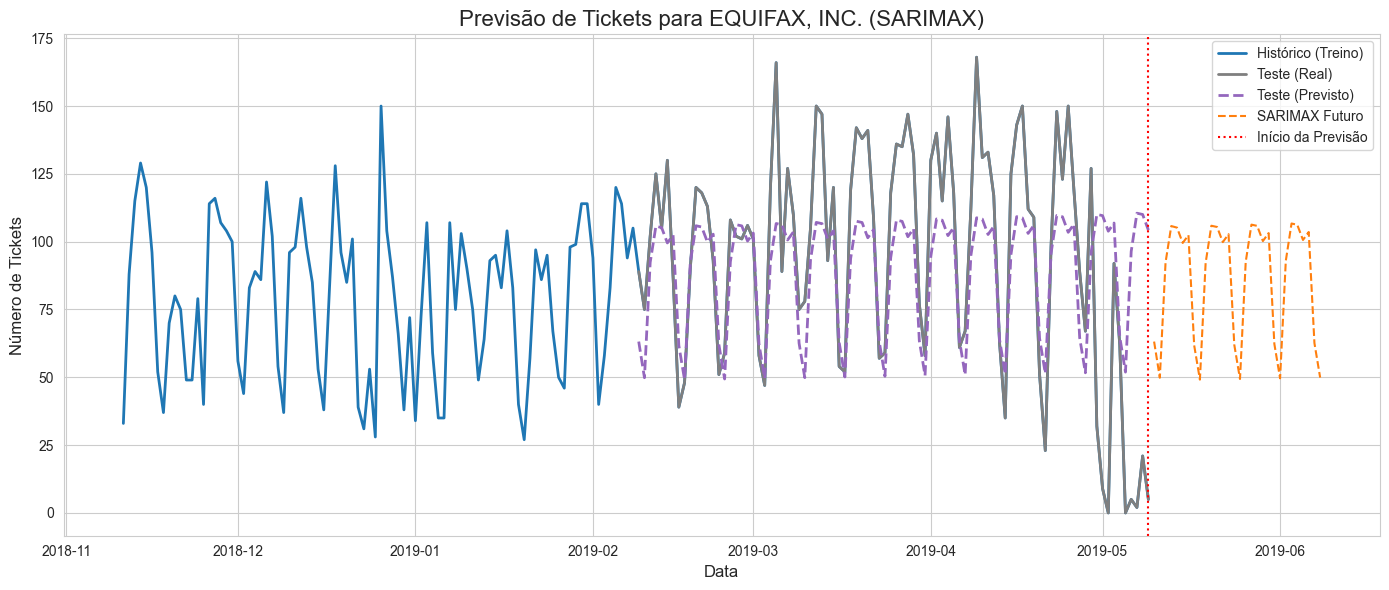

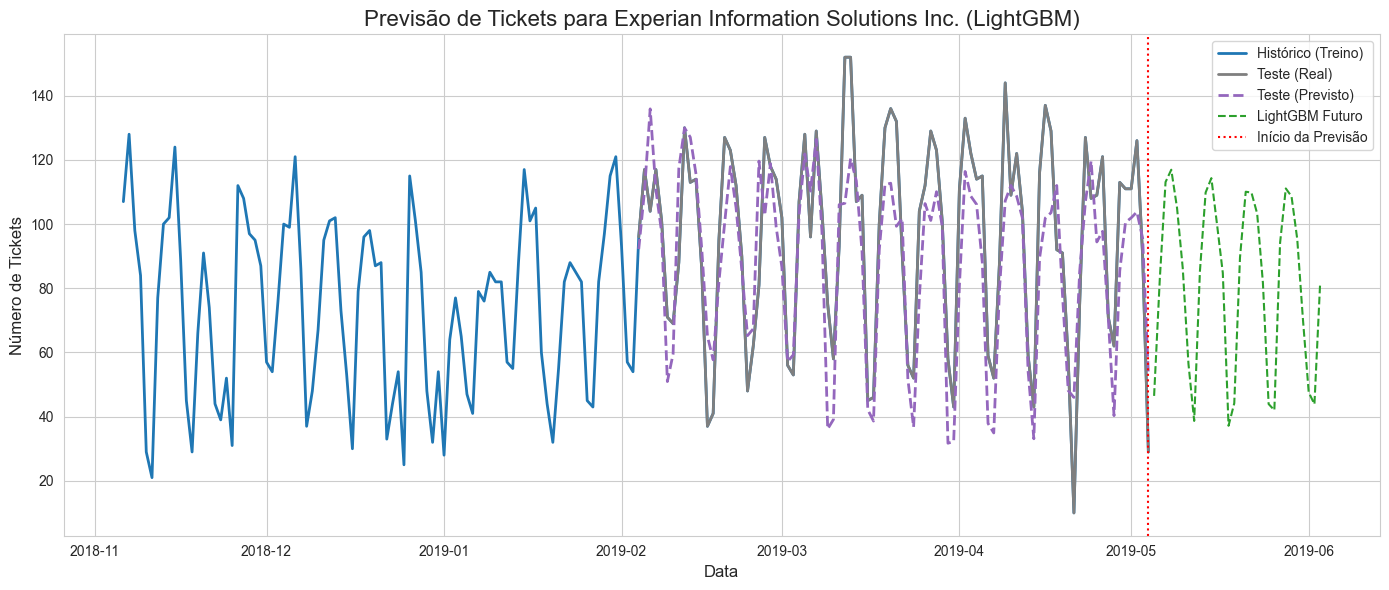

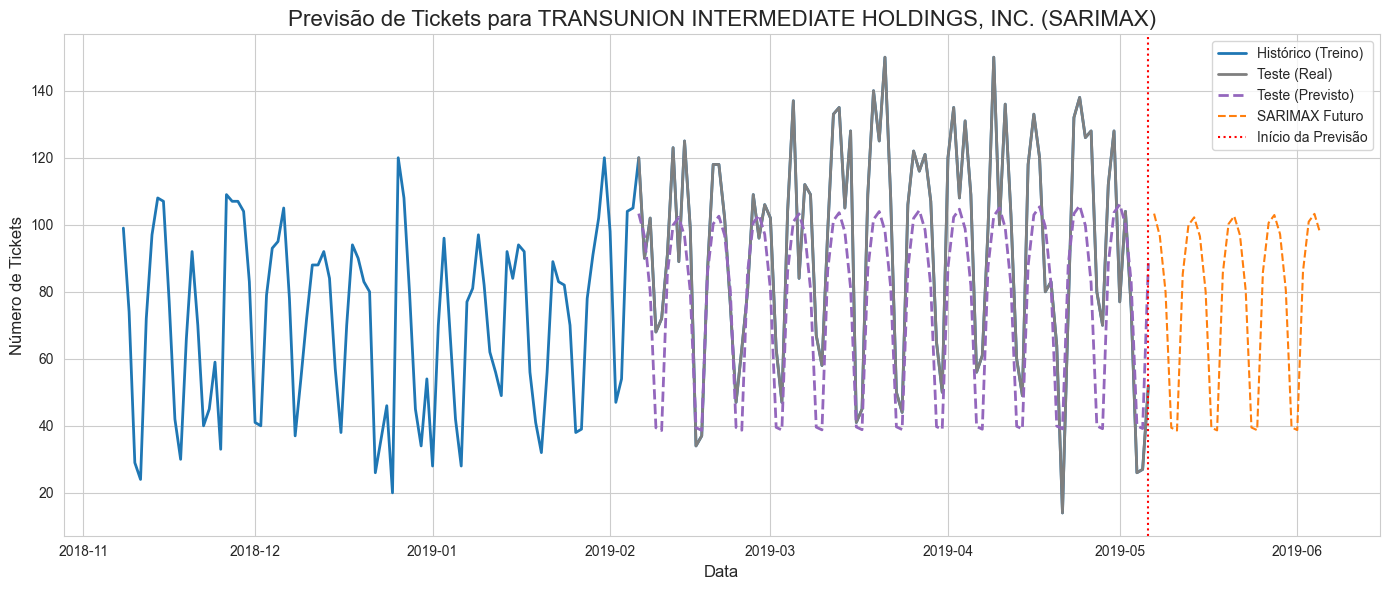

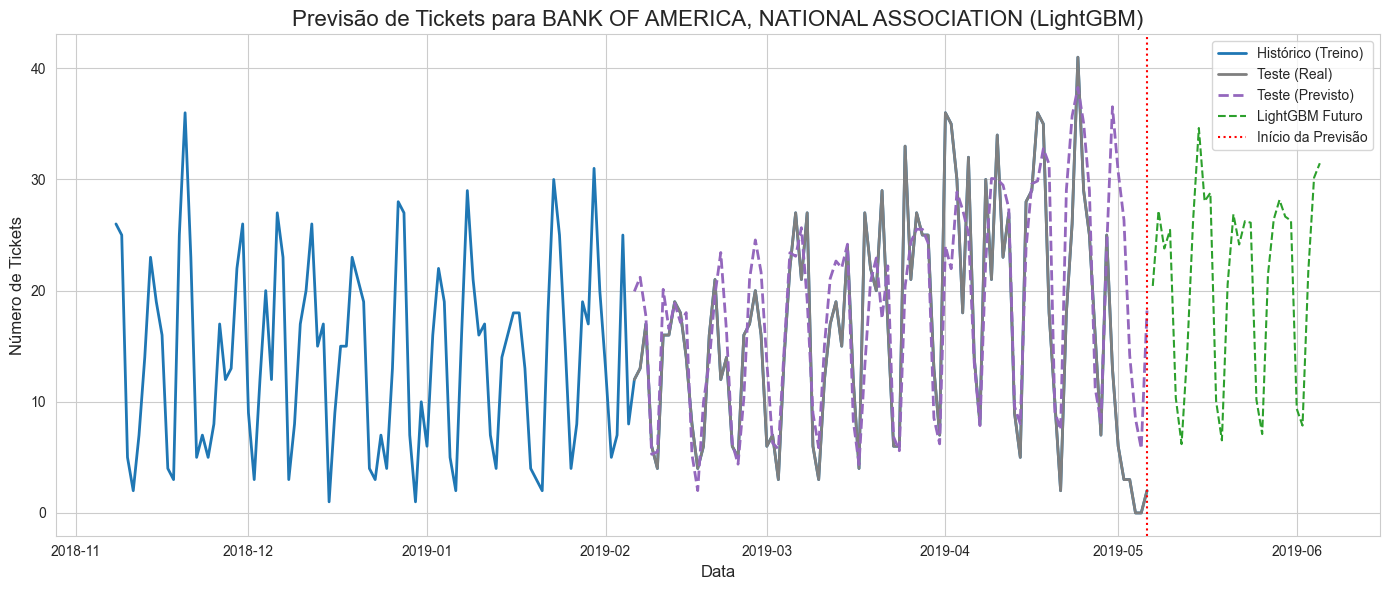

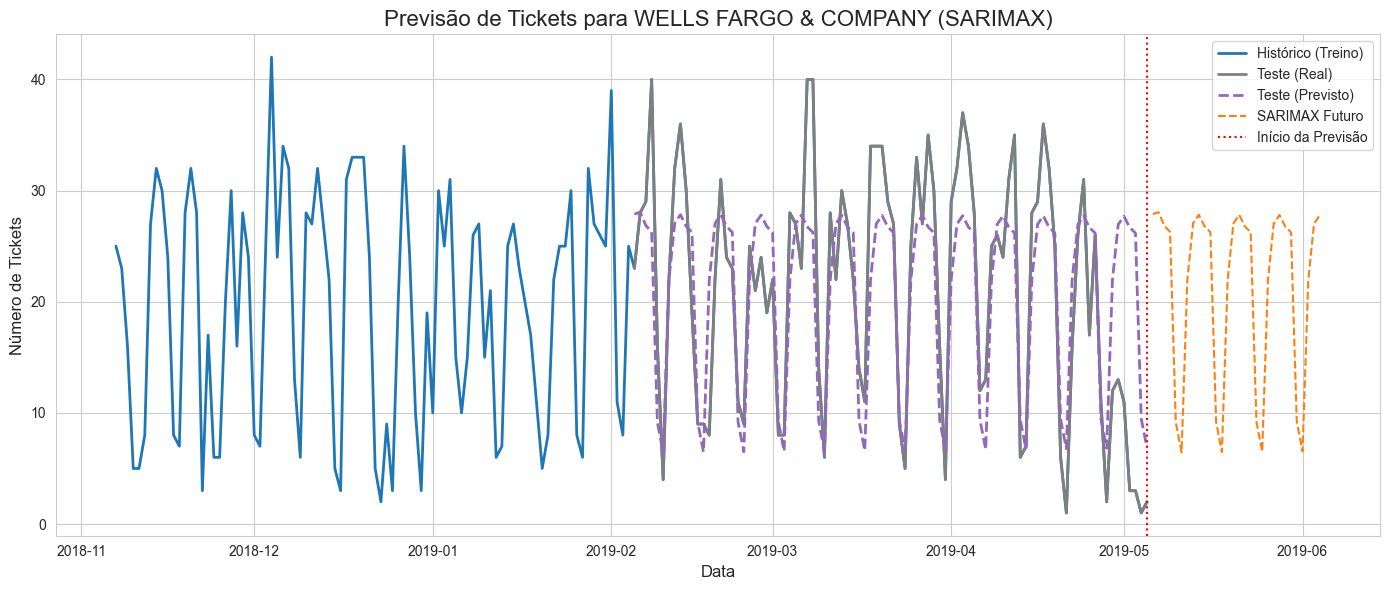

In [222]:
print("Iniciando o Pipeline de Previsão...")
forecast_summary = run_pipeline(CSV_PATH)
if forecast_summary:
    print("\n" + "="*50)
    print("Gerando Gráficos de Previsão...")
    print("="*50)
    plot_results(forecast_summary)